For training trajectories and accuracies, code is taken (and modified) from analysis.ipynb of the main branch: https://github.com/kristinakobrock/emergent-abstractions/blob/main/analysis.ipynb


For entropy scores, code is taken (and modified) from evaluate_metrics.ipynb of the main branch: https://github.com/kristinakobrock/emergent-abstractions/blob/main/evaluate_metrics.ipynb

In order for early_stopping to work, code in load_results.py has beem modified as well.

In [1]:
#from analysis.ipynb of the main branch
from utils.load_results import *
from utils.plot_helpers import *
from utils.analysis_from_interaction import error_analysis

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('default')
import random
from seaborn.algorithms import bootstrap

#from evaluate_metrics.ipynb of the main branch
import pickle
from utils.analysis_from_interaction import *
from egg.core.language_analysis import Disent
from language_analysis_local import TopographicSimilarityConceptLevel, encode_target_concepts_for_topsim
import os

C:\Users\metel\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\metel\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


D(3,3) Split, No length cost, Vocab size 13

 5 runs

HDA - highly discriminative attribute

HDA Indices in each run: 1, 0, 2, 1, 0

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # always context-aware
shared_context = True
split_by_attribute = True
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"

In [3]:
# get n_epochs if early stopping
# taken from  evaluate_metrics.ipynb of the main branch
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[43, 91, 53, 50, 40]]


Accuracies

In [56]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,3)': (0.995, 0.005)}
final_accuracies_val  {'(3,3)': (0.974, 0.013)}
test_accuracies  [array([[0.92684513, 0.99011916, 0.95238096, 0.96565092, 0.98232138]])]
final_accuracies_test  {'(3,3)': (0.963, 0.023)}


Training Trajectories

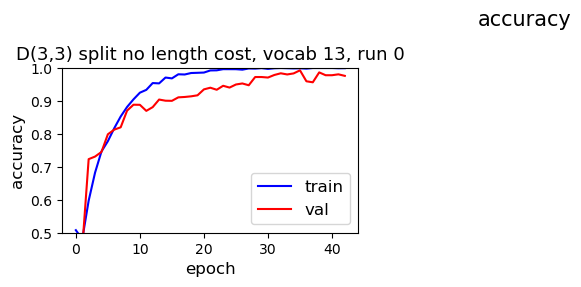

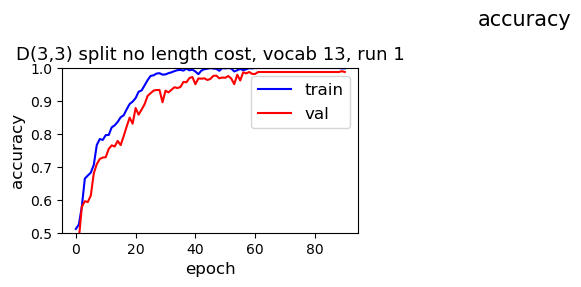

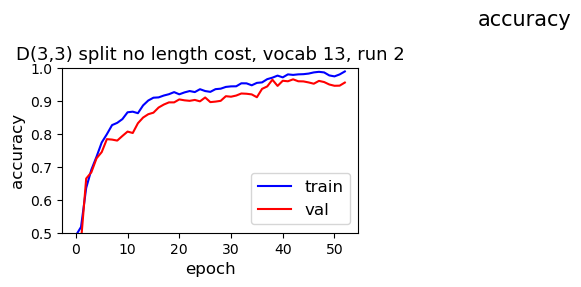

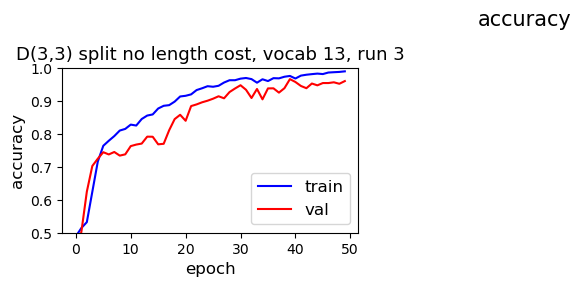

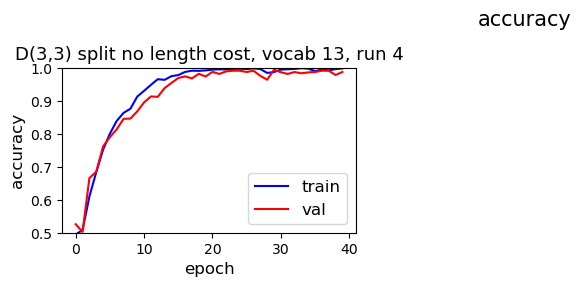

In [57]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,3) split no length cost, vocab 13, run ' + str(run),))

Entropy scores

In [4]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [35]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [61]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.49, Std: 0.02

effectiveness - Mean: 0.41, Std: 0.03

consistency - Mean: 0.62, Std: 0.02



For test interactions:

In [5]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:357: RuntimeWarning: invalid value encountered in divide
  normalized_MI_context_dep = ((m_entropy_context_dep + c_entropy_context_dep - joint_entropy_context_dep)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:367: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_context_dep = ((joint_entropy_context_dep - m_entropy_context_dep)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Us

In [8]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.54, Std: 0.01

effectiveness - Mean: 0.44, Std: 0.02

consistency - Mean: 0.69, Std: 0.03



D(3,3) No split (shared_context), No Length cost, vocab 13

5 runs

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = False
length_cost = False
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[48, 32, 74, 32, 59]]


In [10]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,3)': (0.998, 0.002)}
final_accuracies_val  {'(3,3)': (0.995, 0.002)}
test_accuracies  [array([[0.99099994, 0.99833333, 0.99851853, 0.97233325, 0.99125004]])]
final_accuracies_test  {'(3,3)': (0.99, 0.01)}


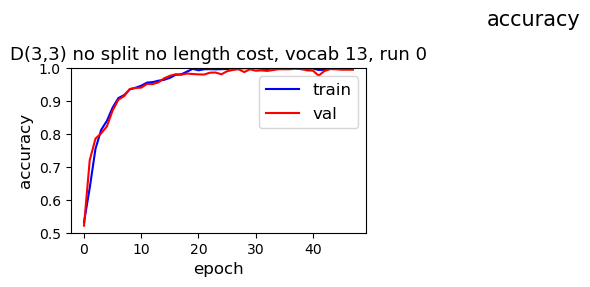

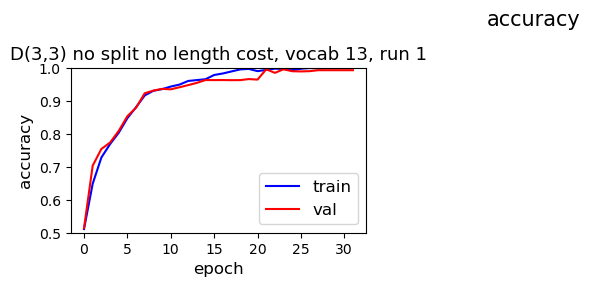

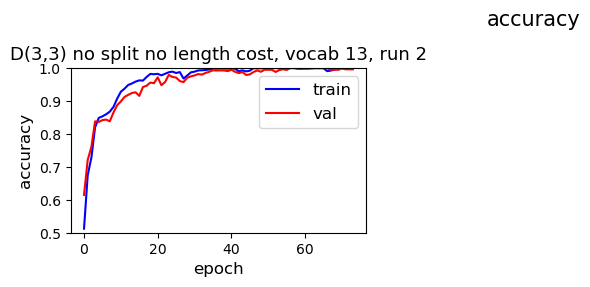

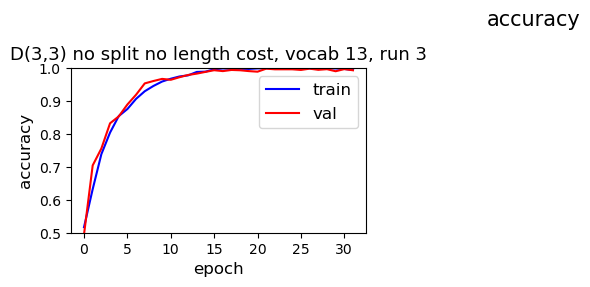

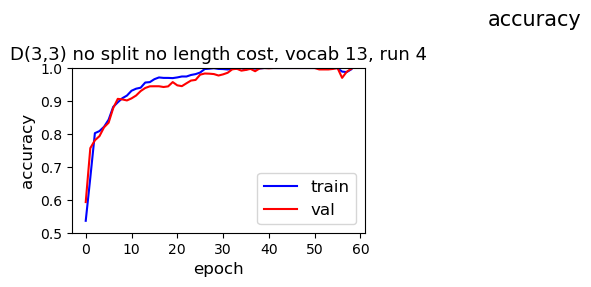

In [64]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,3) no split no length cost, vocab 13, run ' + str(run),))

In [11]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [41]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [69]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.50, Std: 0.01

effectiveness - Mean: 0.41, Std: 0.01

consistency - Mean: 0.64, Std: 0.01



For test interactions:

In [12]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:365: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_hierarchical = ((joint_entropy_hierarchical - m_entropy_hierarchical)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_en

NMI - Mean: 0.59, Std: 0.03

effectiveness - Mean: 0.56, Std: 0.03

consistency - Mean: 0.62, Std: 0.03



D(3,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 0, 0

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False 
shared_context = True
split_by_attribute = True
length_cost = False
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[69, 39]]


In [71]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,4)': (1.0, 0.0)}
final_accuracies_val  {'(3,4)': (0.986, 0.006)}
test_accuracies  [array([[0.96937156, 0.94851428]])]
final_accuracies_test  {'(3,4)': (0.959, 0.01)}


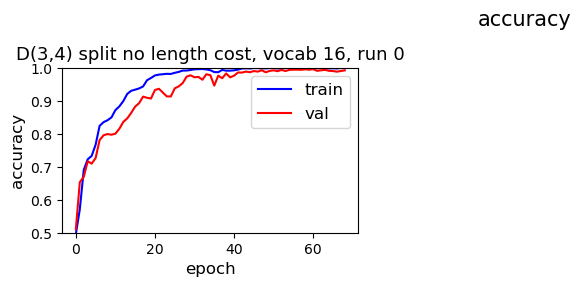

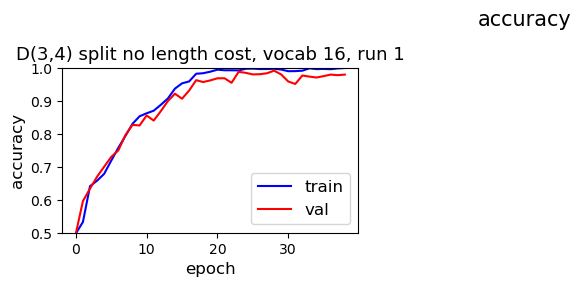

In [72]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,4) split no length cost, vocab 16, run ' + str(run),))

In [14]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [74]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [76]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.51, Std: 0.02

effectiveness - Mean: 0.41, Std: 0.03

consistency - Mean: 0.67, Std: 0.01



Scores from test interactions:

In [15]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:357: RuntimeWarning: invalid value encountered in divide
  normalized_MI_context_dep = ((m_entropy_context_dep + c_entropy_context_dep - joint_entropy_context_dep)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:367: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_context_dep = ((joint_entropy_context_dep - m_entropy_context_dep)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:376: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_context_dep = (joint_entropy_context_dep - c_entropy_context_dep) / m_entropy_context_dep


NMI - Mean: 0.53, Std: 0.02

effectiveness - Mean: 0.43, Std: 0.03

consistency - Mean: 0.69, Std: 0.00



D(3,4) No split (shared_context), No Length cost, vocab 16

2 runs

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = False 
length_cost = False 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[66, 53]]


In [78]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,4)': (0.994, 0.005)}
final_accuracies_val  {'(3,4)': (0.99, 0.008)}
test_accuracies  [array([[0.97392929, 0.98385239]])]
final_accuracies_test  {'(3,4)': (0.979, 0.005)}


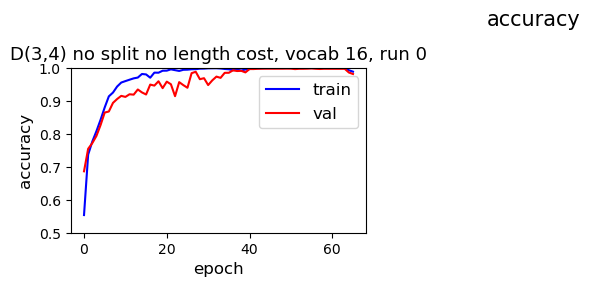

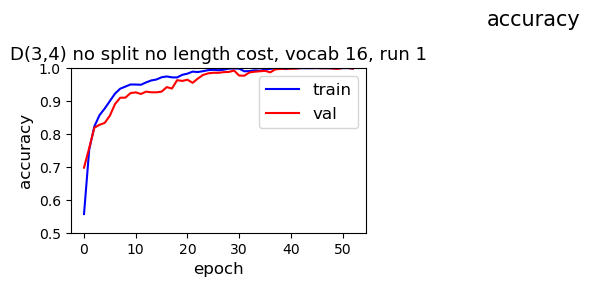

In [79]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,4) no split no length cost, vocab 16, run ' + str(run),))

In [17]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [81]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [84]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.51, Std: 0.01

effectiveness - Mean: 0.41, Std: 0.01

consistency - Mean: 0.65, Std: 0.00



Scores from test interactions:

In [18]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.58, Std: 0.01

effectiveness - Mean: 0.53, Std: 0.01

consistency - Mean: 0.63, Std: 0.01



D(4,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 3, 2

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = True 
length_cost = False 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[48, 65]]


In [86]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(4,4)': (0.997, 0.002)}
final_accuracies_val  {'(4,4)': (0.991, 0.002)}
test_accuracies  [array([[0.98198175, 0.9721927 ]])]
final_accuracies_test  {'(4,4)': (0.977, 0.005)}


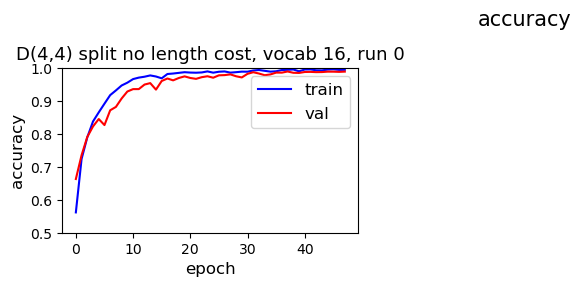

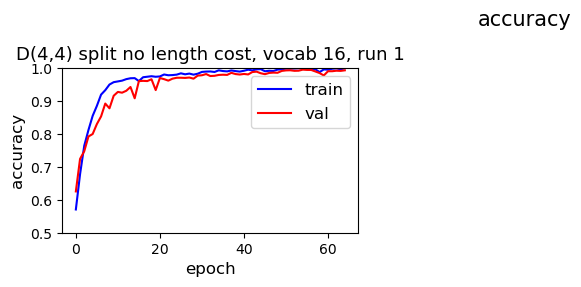

In [87]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(4,4) split no length cost, vocab 16, run ' + str(run),))

In [20]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [89]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [92]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.53, Std: 0.02

effectiveness - Mean: 0.44, Std: 0.03

consistency - Mean: 0.66, Std: 0.00



Scores from test interactions:

In [21]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.53, Std: 0.00

effectiveness - Mean: 0.45, Std: 0.00

consistency - Mean: 0.64, Std: 0.00



D(4,4) No split (shared_context), No Length cost vocab 16

2 runs

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = False 
length_cost = False 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[40, 33]]


In [94]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(4,4)': (0.999, 0.001)}
final_accuracies_val  {'(4,4)': (0.999, 0.001)}
test_accuracies  [array([[0.99818069, 0.99861389]])]
final_accuracies_test  {'(4,4)': (0.998, 0.0)}


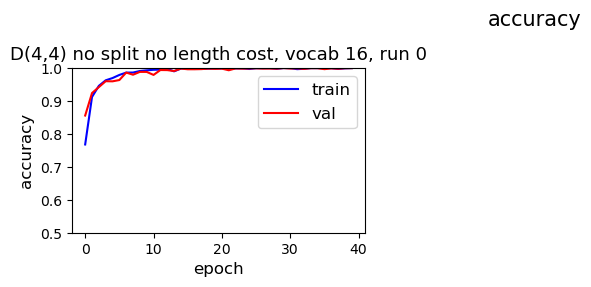

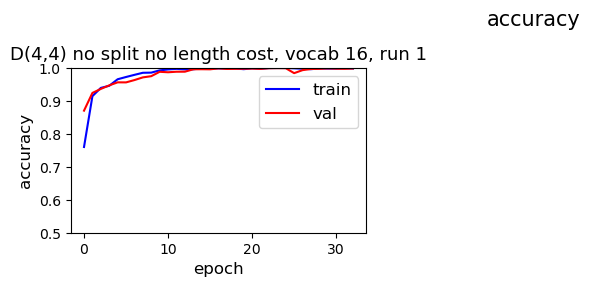

In [95]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(4,4) no split no length cost, vocab 16, run ' + str(run),))

In [23]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [97]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [100]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.50, Std: 0.01

effectiveness - Mean: 0.43, Std: 0.01

consistency - Mean: 0.60, Std: 0.00



Scores from test interactions:

In [24]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.53, Std: 0.02

effectiveness - Mean: 0.47, Std: 0.03

consistency - Mean: 0.60, Std: 0.00



D(3,8) Split, No Length cost, vocab 28

2 runs

HDA indices in each run: 2, 1

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = True
length_cost = False 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[79, 73]]


In [102]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,8)': (0.996, 0.001)}
final_accuracies_val  {'(3,8)': (0.99, 0.002)}
test_accuracies  [array([[0.9777205 , 0.98102307]])]
final_accuracies_test  {'(3,8)': (0.979, 0.002)}


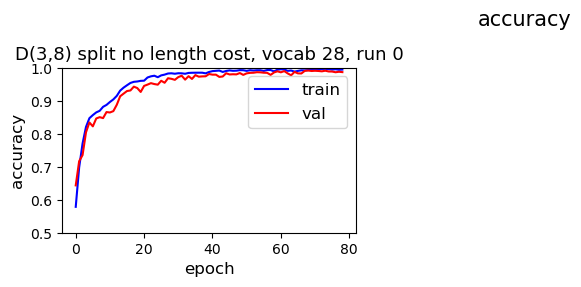

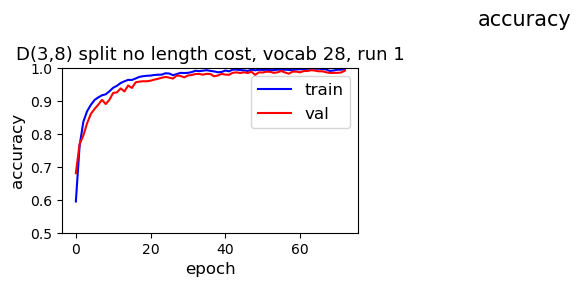

In [103]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,8) split no length cost, vocab 28, run ' + str(run),))

In [26]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [105]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [106]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.56, Std: 0.00

effectiveness - Mean: 0.46, Std: 0.01

consistency - Mean: 0.72, Std: 0.00



Scores from test interactions:

In [27]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.60, Std: 0.00

effectiveness - Mean: 0.49, Std: 0.00

consistency - Mean: 0.75, Std: 0.00



D(3,8) No split (shared_context), No Length cost, vocab 28

2 runs

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = False
length_cost = False 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[44, 41]]


In [108]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, length_cost=length_cost, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,8)': (0.995, 0.002)}
final_accuracies_val  {'(3,8)': (0.993, 0.002)}
test_accuracies  [array([[0.9873963 , 0.99202895]])]
final_accuracies_test  {'(3,8)': (0.99, 0.002)}


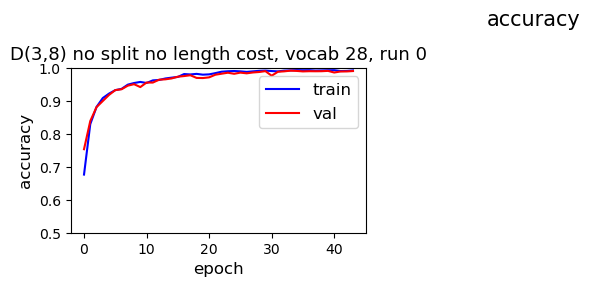

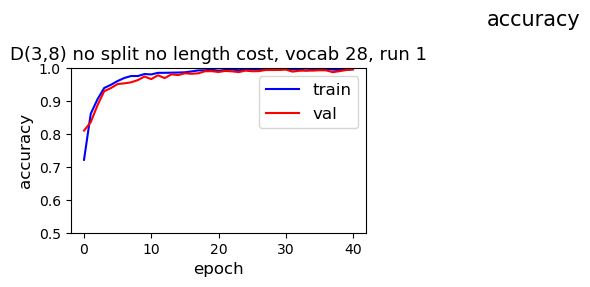

In [109]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,8) no split no length cost, vocab 28, run ' + str(run),))

In [29]:
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [111]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [112]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.53, Std: 0.00

effectiveness - Mean: 0.42, Std: 0.01

consistency - Mean: 0.70, Std: 0.00



Scores from test interactions:

In [30]:
test_interactions = True
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost, test_interactions=test_interactions, test_mode = 'test') 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.60, Std: 0.00

effectiveness - Mean: 0.52, Std: 0.00

consistency - Mean: 0.71, Std: 0.01



Datasets with message length cost and smaller vocab size

D(3,3) Split, Length cost 0.002, vocab 10

2 runs

HDA indices in each run: 1, 2

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False 
shared_context = True
split_by_attribute = True 
length_cost = True 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[78, 73]]


In [161]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,3)': (0.995, 0.005)}
final_accuracies_val  {'(3,3)': (0.992, 0.001)}
test_accuracies  [array([[0.98231214, 0.98658478]])]
final_accuracies_test  {'(3,3)': (0.984, 0.002)}


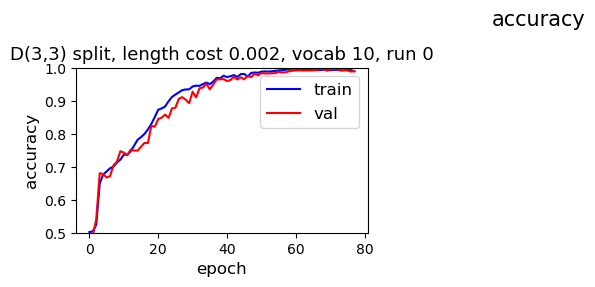

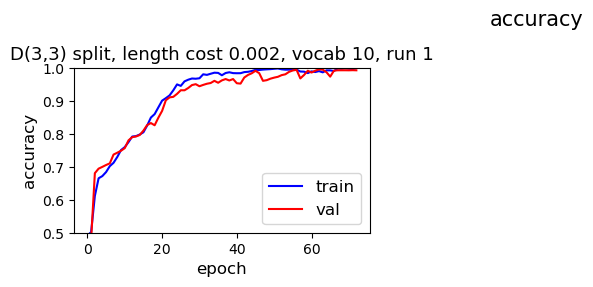

In [162]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,3) split, length cost 0.002, vocab 10, run ' + str(run),))

In [163]:
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [164]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [165]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.48, Std: 0.00

effectiveness - Mean: 0.39, Std: 0.00

consistency - Mean: 0.64, Std: 0.00



D(3,3) No Split (shared_context), Length cost 0.002, vocab 10

2 runs

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False 
shared_context = True
split_by_attribute = False 
length_cost = True 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[34, 48]]


In [167]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,3)': (0.989, 0.005)}
final_accuracies_val  {'(3,3)': (0.975, 0.014)}
test_accuracies  [array([[0.93083161, 0.93722212]])]
final_accuracies_test  {'(3,3)': (0.934, 0.003)}


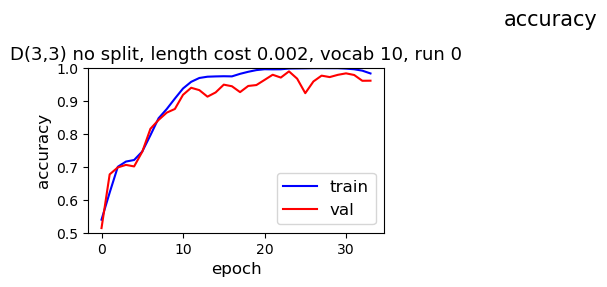

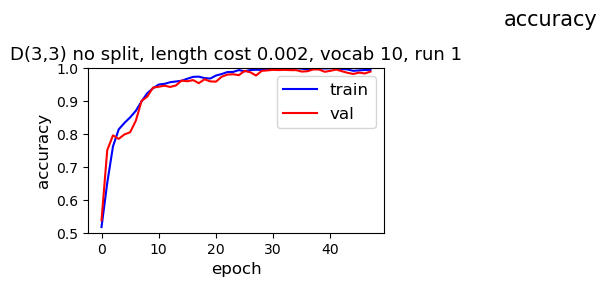

In [168]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,3) no split, length cost 0.002, vocab 10, run ' + str(run),))

In [169]:
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [170]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [171]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.51, Std: 0.00

effectiveness - Mean: 0.45, Std: 0.02

consistency - Mean: 0.58, Std: 0.03



D(3,4) Split, Length cost 0.002, vocab 13

2 runs

HDA indices in each run: 2, 0

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False 
shared_context = True
split_by_attribute = True
length_cost = True
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[72, 72]]


In [173]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,4)': (0.997, 0.002)}
final_accuracies_val  {'(3,4)': (0.979, 0.001)}
test_accuracies  [array([[0.97648543, 0.95365721]])]
final_accuracies_test  {'(3,4)': (0.965, 0.011)}


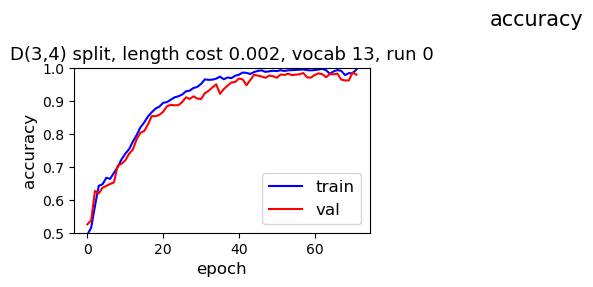

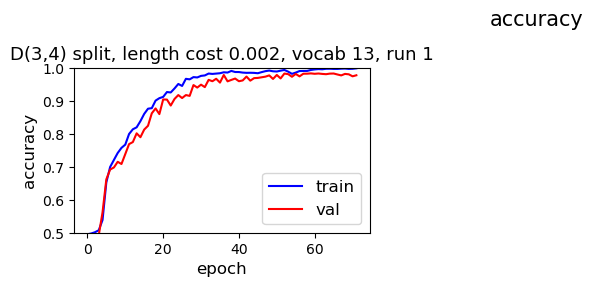

In [174]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,4) split, length cost 0.002, vocab 13, run ' + str(run),))

In [175]:
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [176]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [177]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.52, Std: 0.00

effectiveness - Mean: 0.44, Std: 0.01

consistency - Mean: 0.66, Std: 0.02



D(3,4) No Split (shared_context), Length cost 0.002, vocab 13

2 runs

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False
shared_context = True
split_by_attribute = False 
length_cost = True 
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
#taken from  evaluate_metrics.ipynb
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
print(n_epochs_all_data)

[[40, 31]]


In [179]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        all_accuracies = load_accuracies(paths, n_runs=n_runs, n_epochs=n_epochs[run], val_steps=1, zero_shot=False, context_unaware=context_unaware, early_stopping=early_stopping, shared_context=shared_context, split_by_attribute=split_by_attribute, split_test_ds=split_test_ds)
        accuracies = [all_accuracies['train_acc'], all_accuracies['val_acc']]
        test_accuracies = [all_accuracies['test_acc']]
        
        
final_accuracies_train = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['train_acc'][i][run][-1])
    final_accuracies_train[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
print("final_accuracies_train ", final_accuracies_train)


final_accuracies_val = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['val_acc'][i][run][-1])
    final_accuracies_val[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_val
print("final_accuracies_val ", final_accuracies_val)

print("test_accuracies ", test_accuracies)

final_accuracies_test = {}
for i, d in enumerate(datasets):
    gather_accuracies = []
    for run in range(n_runs):
        gather_accuracies.append(all_accuracies['test_acc'][i][run])
    final_accuracies_test[d] = (round(np.mean(gather_accuracies), 3), round(np.std(gather_accuracies), 3))
final_accuracies_test
print("final_accuracies_test ", final_accuracies_test)

final_accuracies_train  {'(3,4)': (0.999, 0.001)}
final_accuracies_val  {'(3,4)': (0.995, 0.0)}
test_accuracies  [array([[0.98068184, 0.98928571]])]
final_accuracies_test  {'(3,4)': (0.985, 0.004)}


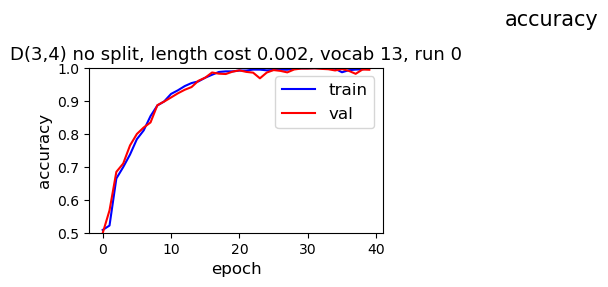

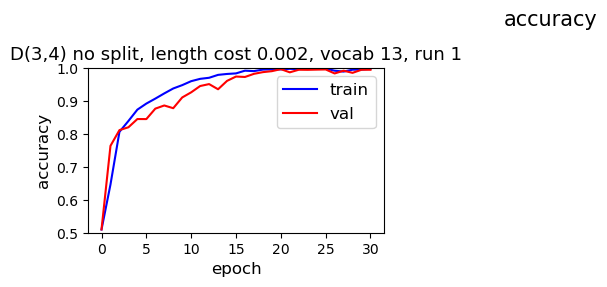

In [180]:
for d in range(len(datasets)):

    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):
        train_traj = all_accuracies['train_acc'][d][run]
        val_traj = all_accuracies['val_acc'][d][run]  
        plot_training_trajectory([train_traj], [val_traj], ylim=(0.5, 1), steps=(1, 1), plot_indices=[1], n_epochs=n_epochs[run], titles = ('D(3,4) no split, length cost 0.002, vocab 13, run ' + str(run),))

In [181]:
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [182]:
test_interactions = False
zero_shot_test_ds = split_test_ds
for d in range(len(datasets)):
    
    n_epochs = n_epochs_all_data[d]
    for run in range(n_runs):

        path_to_run = paths[d] + '/' + str(setting) +'/' + str(run) + '/' 
        if not rsa:
            if not test_interactions:
                path_to_interaction = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
            else:
                path_to_interaction = (path_to_run + 'interactions/' + zero_shot_test_ds + '/epoch_0/interaction_gpu0')
        else:
            path_to_rsa = (path_to_run + 'rsa/' + rsa_test + '/')
            path_to_interaction = (path_to_rsa + 'rsa_' + rsa_test + '/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        interaction = torch.load(path_to_interaction, weights_only=False)

        attributes = n_attributes[d]
        values = n_values[d]
        scores = information_scores(interaction, attributes, values, normalizer="arithmetic")
        
        if not rsa:
            if not test_interactions:
                pickle.dump(scores, open(path_to_run + 'entropy_scores.pkl', 'wb'))
            else:
                pickle.dump(scores, open(path_to_run + 'entropy_scores_' + zero_shot_test_ds + '.pkl', 'wb'))
        else:
            pickle.dump(scores, open(path_to_rsa + 'entropy_scores.pkl', 'wb'))

c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_conc_x_cont = ((joint_entropy_concept_x_context - m_entropy_concept_x_context)
c:\Users\metel\OneDrive\Документы\new_branch_repository\utils\analysis_from_interaction.py:377: RuntimeWarning: invalid value encountered in divide
  normalized_consistency_conc_x_cont = (joint_entropy_concept_x_context - c_entropy_concept_x_context) / m_entropy_concept_x_context


In [183]:
# in the evaluate_metric.ipynb of the main branch, entropy scores are presented as heatmap plots
# but here, I am just printing the values for simplicity
entropy_scores = load_entropies(paths, context_unaware=context_unaware, n_runs=n_runs, split_by_attribute=split_by_attribute, shared_context=shared_context, length_cost=length_cost) 
metrics = ['NMI', 'effectiveness', 'consistency']
n_runs = n_runs

for metric in metrics:
    scores = entropy_scores[metric][0]  # [0] for the first dataset
    #for run_idx in range(n_runs):
        #print(f"{metric} - Run {run_idx}: {scores[run_idx]:.2f}")
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{metric} - Mean: {mean_score:.2f}, Std: {std_score:.2f}\n")

NMI - Mean: 0.52, Std: 0.00

effectiveness - Mean: 0.44, Std: 0.01

consistency - Mean: 0.63, Std: 0.01

